# **ASSIGNMENT 5**: Morphological operations

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

### **Helper** Functions
---

In [130]:
def load_image(path: str):
    try:
        img = Image.open(path)
        img.load()
        print("Image loaded successfully!")
        return img
    except FileNotFoundError:
        print("Error: Image not found.")
        return None
    except OSError:
        print("Error: File is not a valid image.")
        return None

In [131]:
def verify_convert(img: Image.Image):
    if img.mode == "L":
        print("Image is already 8-bit grayscale.")
        return img
    else:
        print(f"Image mode is {img.mode}. Converting it to 8-bit grayscale ...")
        return img.convert("L")

In [132]:
def print_image(img: Image.Image, title="Image"):
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()

In [133]:
def to_array(img):
    return np.array(img, dtype=np.int32)


In [134]:
def to_image(array):
    arr = np.clip(array, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)


In [135]:
def resize_image(img, max_size=600):
    w, h = img.size
    if max(w, h) <= max_size:
        return img
    if w > h:
        new_w = max_size
        new_h = int(h * (max_size / w))
    else:
        new_h = max_size
        new_w = int(w * (max_size / h))
    
    return img.resize((new_w, new_h), Image.LANCZOS)

### Functions for **TASK 1**
---

`EROSION`

In [136]:
def erosion(img_array, kernel_size=3):
    height, width = img_array.shape
    d = kernel_size // 2 

    new = img_array.copy()

    for i in range(d, height - d):
        for j in range(d, width - d):
            
            neighborhood = []
            for a in range(-d, d+1):
                for b in range(-d, d+1):
                    neighborhood.append(img_array[i + a, j + b])

            new[i, j] = min(neighborhood)

    return new

`DILATION`

In [137]:
def dilation(img_array, kernel_size=3):
    height, width = img_array.shape
    d = kernel_size // 2

    new = img_array.copy()

    for i in range(d, height - d):
        for j in range(d, width - d):

            neighborhood = []
            for a in range(-d, d+1):
                for b in range(-d, d+1):
                    neighborhood.append(img_array[i + a, j + b])

            new[i, j] = max(neighborhood)

    return new

### Functions for **TASK 2**
---

`OPENING` = **Erosion → Dilation**  

In [138]:
def opening(img_array, kernel_size=3):
    
    # Step 1 – Erode
    eroded = erosion(img_array, kernel_size)
    
    # Step 2 – Dilate
    opened = dilation(eroded, kernel_size)
    
    return opened


`CLOSING` = **Dilation → Erosion** 

In [139]:
def closing(img_array, kernel_size=3):
    
    # Step 1 – Dilate
    dilated = dilation(img_array, kernel_size)
    
    # Step 2 – Erode
    closed = erosion(dilated, kernel_size)
    
    return closed

### **Wrapper** function
---

In [140]:
def apply_morph(img, morph_function, kernel_size=3):
    """
    - converts PIL image to array
    - applies chosen morphological operation
    - converts result back to PIL image
    """
    img_arr = to_array(img)

    processed_arr = morph_function(img_arr, kernel_size)

    return to_image(processed_arr)


---
---

#### **Image 1**

Image loaded successfully!


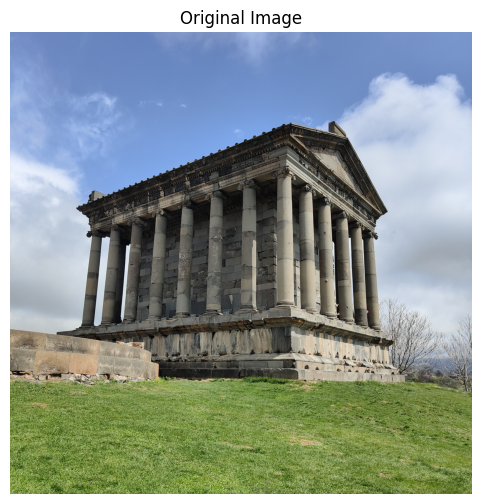

Image mode is RGB. Converting it to 8-bit grayscale ...


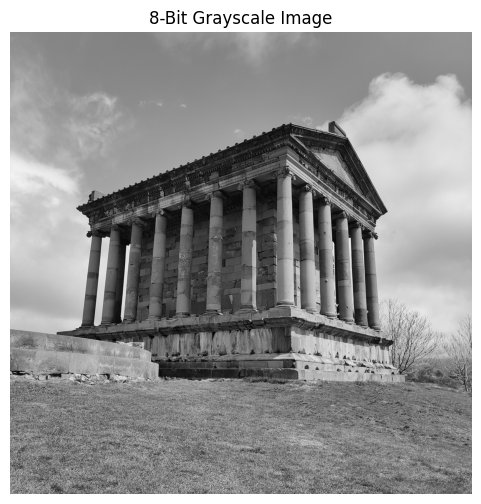

(3072, 3072)


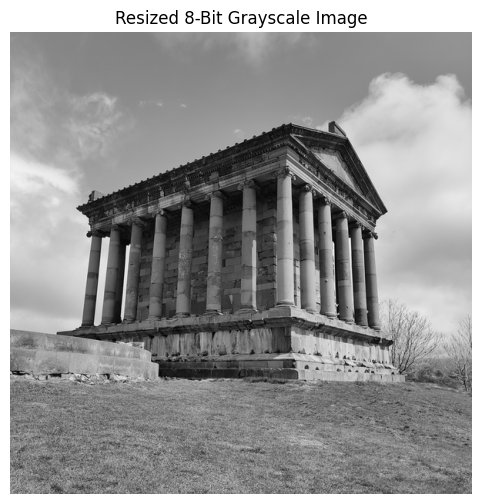

(600, 600)


In [141]:
path = r'C:\Users\cazal\OneDrive\Pictures\Armenia 2025\IMG20250415115301.jpg'
img = load_image(path)
print_image(img, "Original Image")
img = verify_convert(img)
print_image(img, "8-Bit Grayscale Image")
print(img.size)
img = resize_image(img, max_size=600)
print_image(img, "Resized 8-Bit Grayscale Image")
print(img.size)

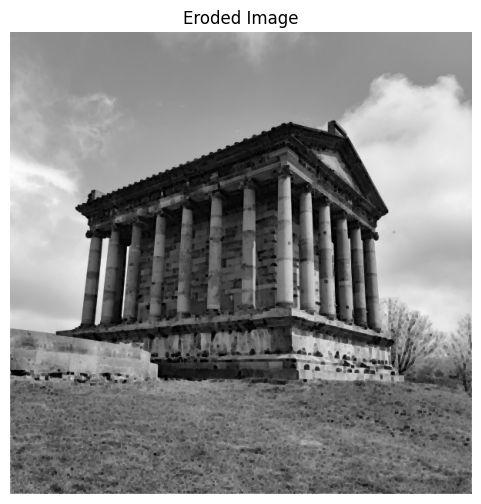

In [142]:
eroded = apply_morph(img, erosion, kernel_size=3)
print_image(eroded, "Eroded Image")

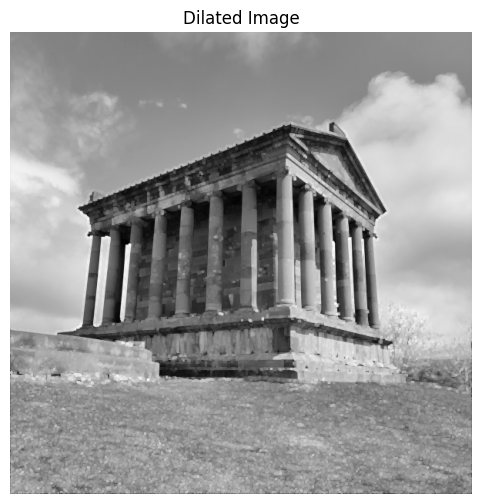

In [143]:
dilated = apply_morph(img, dilation, kernel_size=3)
print_image(dilated, "Dilated Image")

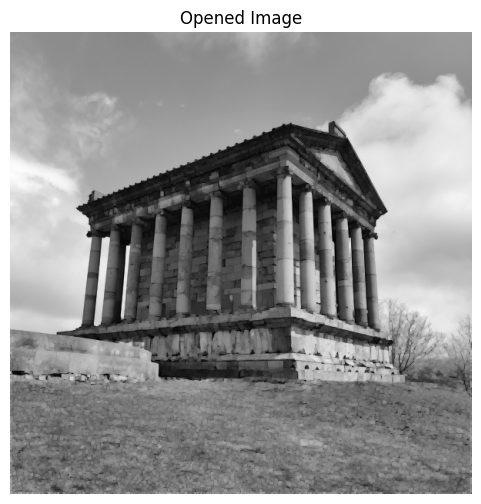

In [144]:
opened = apply_morph(img, opening, kernel_size=3)
print_image(opened, "Opened Image")

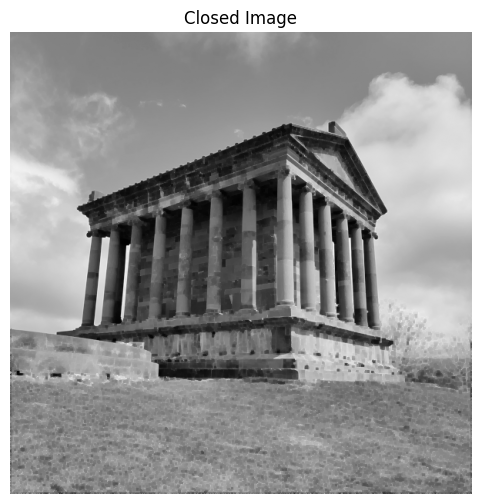

In [145]:
closed = apply_morph(img, closing, kernel_size=3)
print_image(closed, "Closed Image")

#### **Image 2**

Image loaded successfully!


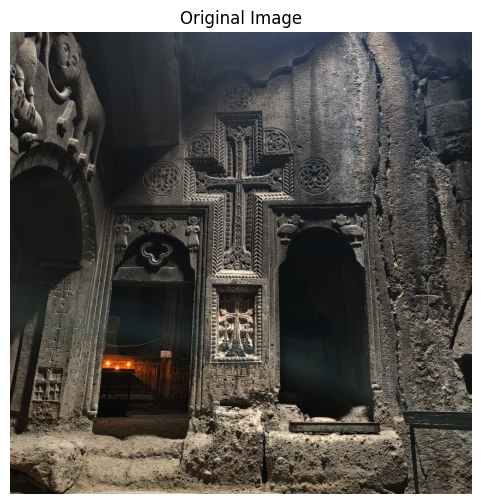

Image mode is RGB. Converting it to 8-bit grayscale ...


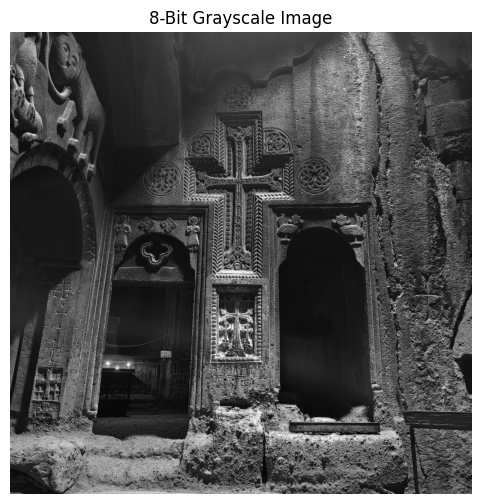

(3072, 3072)


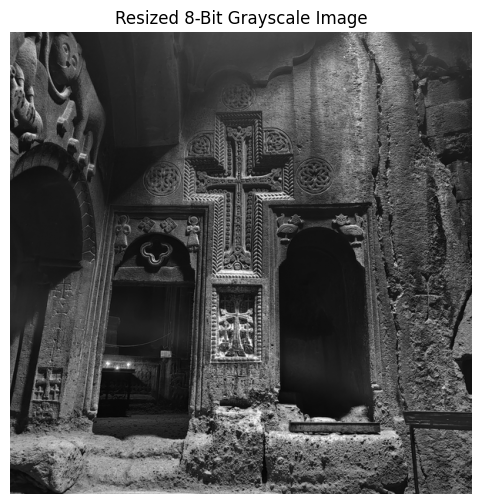

(600, 600)


In [146]:
path = r"C:\Users\cazal\OneDrive\Pictures\Armenia 2025\IMG20250415143956.jpg"
img = load_image(path)
print_image(img, "Original Image")
img = verify_convert(img)
print_image(img, "8-Bit Grayscale Image")
print(img.size)
img = resize_image(img, max_size=600)
print_image(img, "Resized 8-Bit Grayscale Image")
print(img.size)

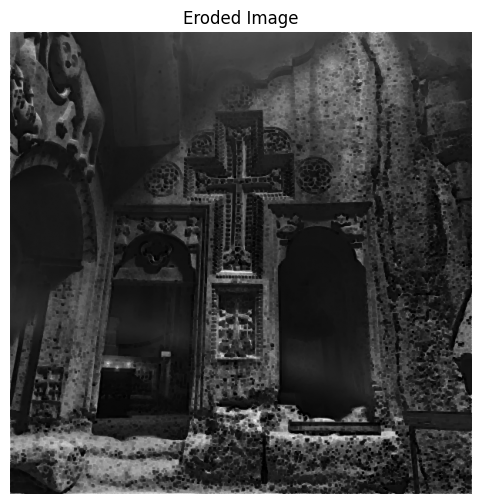

In [147]:
eroded = apply_morph(img, erosion, kernel_size=3)
print_image(eroded, "Eroded Image")

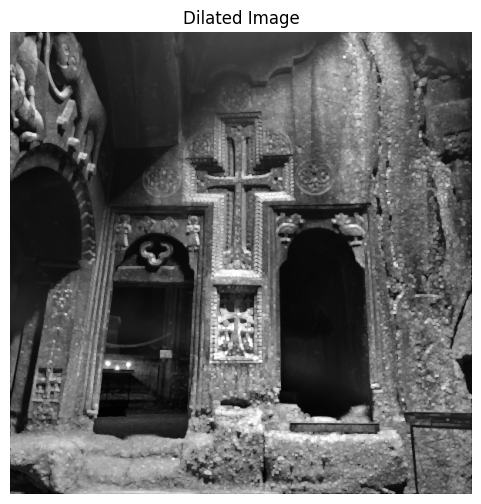

In [148]:
dilated = apply_morph(img, dilation, kernel_size=3)
print_image(dilated, "Dilated Image")

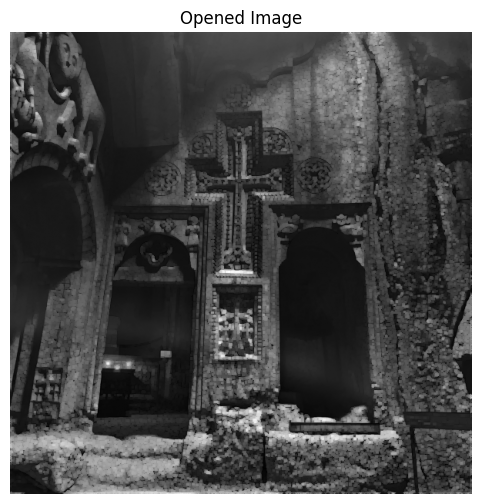

In [149]:
opened = apply_morph(img, opening, kernel_size=3)
print_image(opened, "Opened Image")

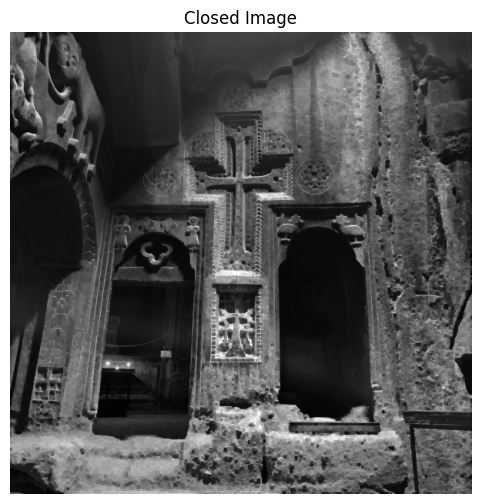

In [150]:
closed = apply_morph(img, closing, kernel_size=3)
print_image(closed, "Closed Image")

#### **Image 3**

Image loaded successfully!


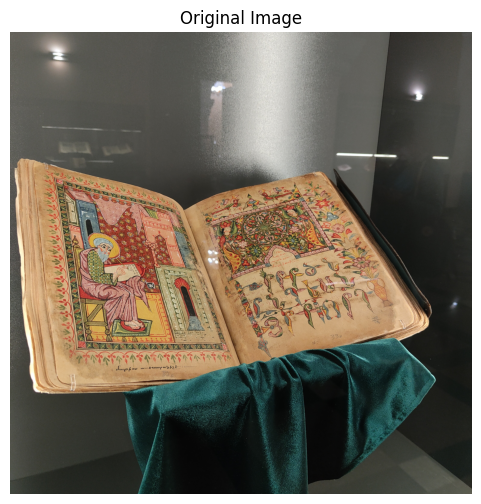

Image mode is RGB. Converting it to 8-bit grayscale ...


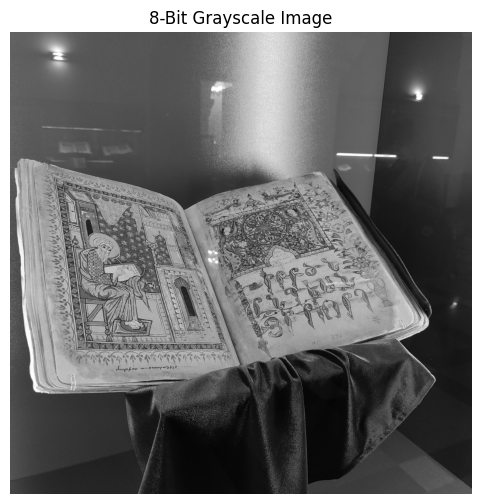

(3072, 3072)


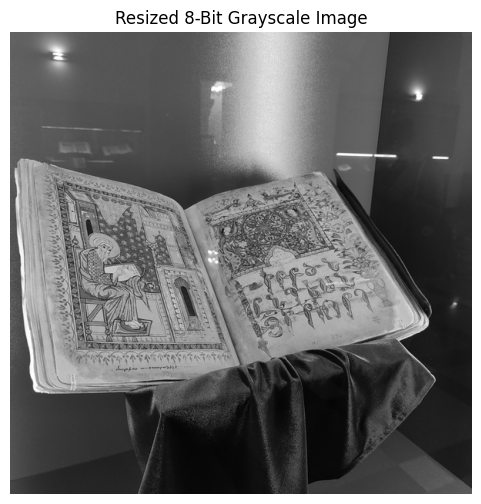

(600, 600)


In [151]:
path = r"C:\Users\cazal\OneDrive\Pictures\Armenia 2025\IMG20250416124815.jpg"
img = load_image(path)
print_image(img, "Original Image")
img = verify_convert(img)
print_image(img, "8-Bit Grayscale Image")
print(img.size)
img = resize_image(img, max_size=600)
print_image(img, "Resized 8-Bit Grayscale Image")
print(img.size)

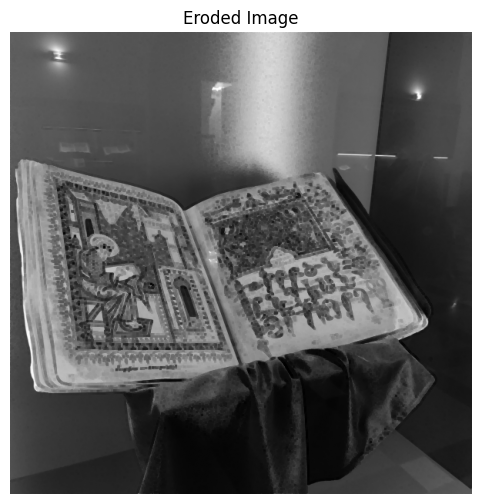

In [152]:
eroded = apply_morph(img, erosion, kernel_size=3)
print_image(eroded, "Eroded Image")

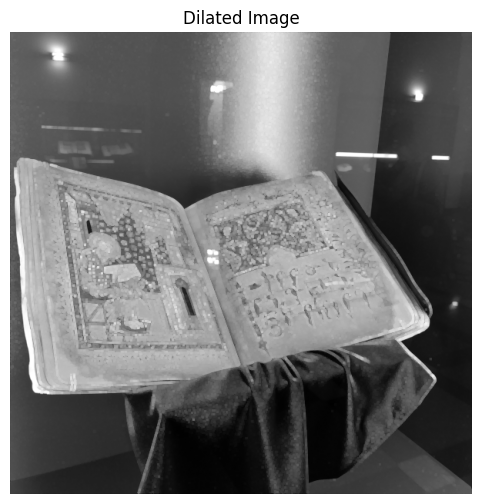

In [153]:
dilated = apply_morph(img, dilation, kernel_size=3)
print_image(dilated, "Dilated Image")

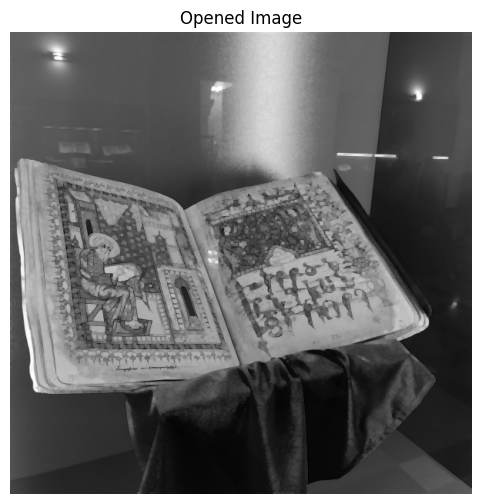

In [154]:
opened = apply_morph(img, opening, kernel_size=3)
print_image(opened, "Opened Image")

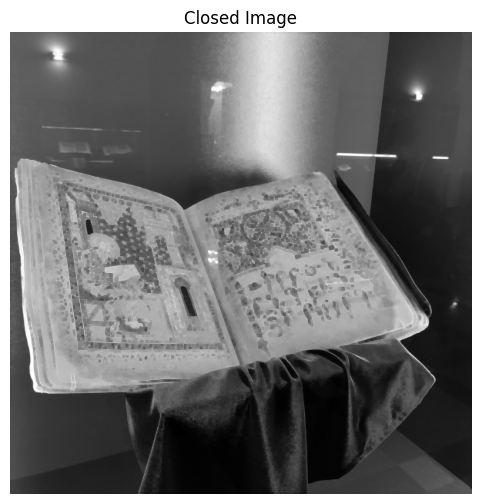

In [155]:
closed = apply_morph(img, closing, kernel_size=3)
print_image(closed, "Closed Image")